# V16-RC5 | High-Score 8C/4S Premium Market Lead

**V16-RC5** combines a compact 8 `COW` / 4 `SHEEP` production route
with a one-turn market lead for `MELON`, `MILK`, `STRAWBERRY`, and
`WOOL`.

The production schedule was reconstructed from three publicly available
Kaggriculture replays of **Nikita Lugovoy's high-ranking submission
`55440039`**: episodes `92165990`, `92185587`, and `92223213`.
Across those traces, the field schedule was identical and the market
schedule matched at 99.91% of decision steps.

In live local simulations against the reconstructed core, V16-RC5 won
**60/60 games across 30 seeds and both seat orders**; all 30 paired
results were positive. The same executable candidate also completed
broad two-seat regression panels against established public artifacts.

These figures are local paired simulations. The competition submission
generated by this notebook follows below.

## 1. Reconstruct the high-throughput route

The three public replays expose a remarkably stable season plan. At each
decision step, the reconstruction takes the majority `farmer`, `hands`,
and `market` action across the three traces. The resulting route:

- expands to three unlocked quadrants;
- reaches 4 `SHEEP` immediately and 8 `COW` by step 192;
- maintains a mixed `WHEAT`, `STRAWBERRY`, and `MELON` crop program;
- coordinates daily `HIRE`, `FEED`, `CARE`, harvest, and fertilizer work;
- releases produce in repeated premium-goods market waves.

The executable version also aligns the action list to the current number
of farm hands and repairs a `WEED` when it blocks a scheduled `PLANT` or
`BUILD_PASTURE`, so the route can recover from state drift on unseen seeds.

In [1]:
import json
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch
from IPython.display import display

plt.rcParams.update({
    "figure.dpi": 130,
    "font.size": 11,
    "axes.titleweight": "bold",
    "axes.titlesize": 16,
    "axes.labelcolor": "#334155",
    "text.color": "#0F172A",
})

NAVY = "#0F172A"
TEAL = "#0F766E"
MINT = "#5EEAD4"
BLUE = "#2563EB"
SLATE = "#64748B"
LIGHT = "#E2E8F0"
ORANGE = "#F97316"

evaluation = pd.DataFrame(json.loads(r'''[{"reference":"Reconstructed 8C/4S core","games":60,"wins":60,"ties":0,"losses":0,"mean_margin":1911.8666666666666,"worst_margin":68.0,"paired_positive":30,"paired_zero":0,"paired_negative":0,"pairs":30},{"reference":"V16-RC4-P5D","games":60,"wins":57,"ties":0,"losses":3,"mean_margin":5460.616666666667,"worst_margin":-529.0,"paired_positive":29,"paired_zero":0,"paired_negative":1,"pairs":30},{"reference":"V16-RC3","games":24,"wins":23,"ties":0,"losses":1,"mean_margin":6105.208333333333,"worst_margin":-28.0,"paired_positive":12,"paired_zero":0,"paired_negative":0,"pairs":12},{"reference":"Kaito V27 public artifact","games":24,"wins":24,"ties":0,"losses":0,"mean_margin":18992.791666666668,"worst_margin":8724.0,"paired_positive":12,"paired_zero":0,"paired_negative":0,"pairs":12},{"reference":"Rayk C71 public artifact","games":24,"wins":24,"ties":0,"losses":0,"mean_margin":18576.75,"worst_margin":9089.0,"paired_positive":12,"paired_zero":0,"paired_negative":0,"pairs":12},{"reference":"llcc public artifact","games":24,"wins":24,"ties":0,"losses":0,"mean_margin":18340.958333333332,"worst_margin":7104.0,"paired_positive":12,"paired_zero":0,"paired_negative":0,"pairs":12}]'''))
expansion = pd.DataFrame(json.loads(r'''[{"step":0,"COW":1,"SHEEP":4},{"step":120,"COW":2,"SHEEP":4},{"step":161,"COW":4,"SHEEP":4},{"step":168,"COW":6,"SHEEP":4},{"step":192,"COW":8,"SHEEP":4},{"step":719,"COW":8,"SHEEP":4}]'''))

assert evaluation.loc[0, "games"] == 60
assert evaluation.loc[0, "wins"] == 60
assert evaluation.loc[0, "paired_positive"] == 30
assert (evaluation["games"] == 2 * evaluation["pairs"]).all()
print("Validated: all displayed results are complete two-seat, 720-turn simulations.")

Validated: all displayed results are complete two-seat, 720-turn simulations.


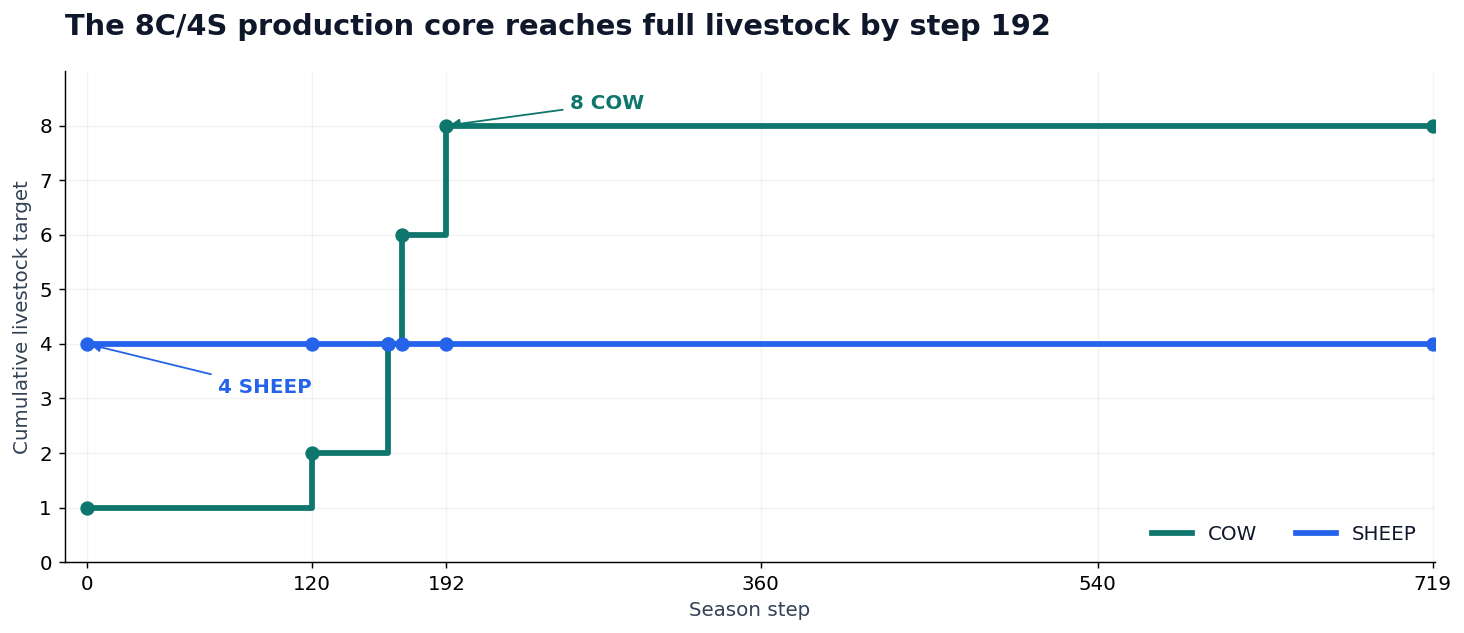

In [2]:
fig, ax = plt.subplots(figsize=(11.4, 5.0))
ax.step(expansion["step"], expansion["COW"], where="post",
        linewidth=3.2, color=TEAL, label="COW")
ax.step(expansion["step"], expansion["SHEEP"], where="post",
        linewidth=3.2, color=BLUE, label="SHEEP")
ax.scatter(expansion["step"], expansion["COW"], s=48, color=TEAL, zorder=3)
ax.scatter(expansion["step"], expansion["SHEEP"], s=48, color=BLUE, zorder=3)
ax.set_xlim(-12, 720)
ax.set_ylim(0, 9)
ax.set_xticks([0, 120, 192, 360, 540, 719])
ax.set_yticks(range(0, 9))
ax.set_xlabel("Season step")
ax.set_ylabel("Cumulative livestock target")
ax.set_title("The 8C/4S production core reaches full livestock by step 192",
             loc="left", pad=20)
ax.grid(alpha=0.16)
ax.spines[["top", "right"]].set_visible(False)
ax.legend(frameon=False, ncol=2, loc="lower right")
ax.annotate("8 COW", xy=(192, 8), xytext=(258, 8.3),
            arrowprops={"arrowstyle": "-|>", "color": TEAL},
            color=TEAL, fontweight="bold")
ax.annotate("4 SHEEP", xy=(0, 4), xytext=(70, 3.1),
            arrowprops={"arrowstyle": "-|>", "color": BLUE},
            color=BLUE, fontweight="bold")
fig.tight_layout()
fig.savefig("livestock_expansion.png", bbox_inches="tight", facecolor="white")
plt.show()

## 2. Add a conservative premium market lead

The shared market rewards queue position: once a `SELL` adds inventory,
later units may receive a lower price. V16-RC5 checks the next scheduled
sale for four premium products. When the current turn has no matching town
demand and the player's own `shed` holds enough stock, it moves part of the
next-turn sale forward by one turn.

The moved quantity is recorded and removed from the original next-turn
order. The two-turn intended quantity stays constant; only its execution
time changes. Purchases, `HIRE` order, and the production schedule remain
unchanged.

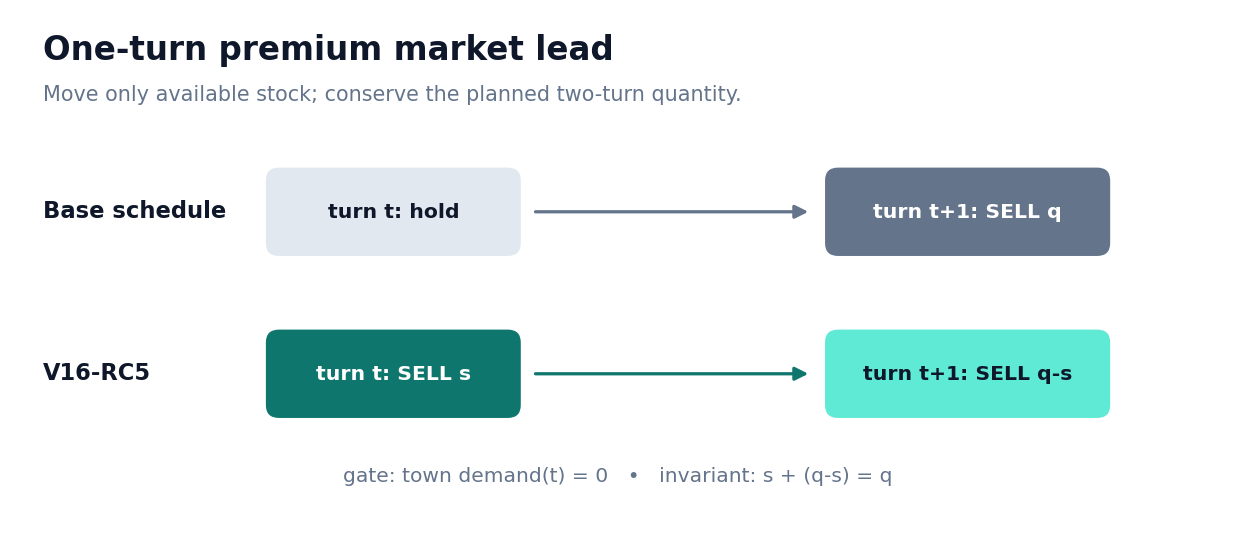

In [3]:
fig, ax = plt.subplots(figsize=(12.0, 5.1))
ax.set_xlim(0, 12)
ax.set_ylim(0, 5.2)
ax.axis("off")

ax.text(0.3, 4.72, "One-turn premium market lead",
        fontsize=18, fontweight="bold", color=NAVY)
ax.text(0.3, 4.30,
        "Move only available stock; conserve the planned two-turn quantity.",
        fontsize=11.5, color=SLATE)

def draw_box(x, y, width, label, color, text_color="white"):
    patch = FancyBboxPatch(
        (x, y), width, 0.82,
        boxstyle="round,pad=0.04,rounding_size=0.13",
        linewidth=0, facecolor=color,
    )
    ax.add_patch(patch)
    ax.text(x + width / 2, y + 0.41, label,
            ha="center", va="center", fontsize=11.3,
            fontweight="bold", color=text_color)

ax.text(0.3, 3.18, "Base schedule", fontsize=12.5,
        fontweight="bold", color=NAVY, va="center")
draw_box(2.55, 2.76, 2.45, "turn t: hold", LIGHT, NAVY)
draw_box(8.10, 2.76, 2.75, "turn t+1: SELL q", SLATE)
ax.add_patch(FancyArrowPatch((5.15, 3.17), (7.93, 3.17),
                             arrowstyle="-|>", mutation_scale=15,
                             linewidth=1.8, color=SLATE))

ax.text(0.3, 1.53, "V16-RC5", fontsize=12.5,
        fontweight="bold", color=NAVY, va="center")
draw_box(2.55, 1.11, 2.45, "turn t: SELL s", TEAL)
draw_box(8.10, 1.11, 2.75, "turn t+1: SELL q-s", MINT, NAVY)
ax.add_patch(FancyArrowPatch((5.15, 1.52), (7.93, 1.52),
                             arrowstyle="-|>", mutation_scale=15,
                             linewidth=1.8, color=TEAL))

ax.text(6.0, 0.42,
        "gate: town demand(t) = 0   •   invariant: s + (q-s) = q",
        ha="center", fontsize=11.2, color=SLATE)
fig.savefig("premium_market_lead.png", bbox_inches="tight", facecolor="white")
plt.show()

## 3. Dynamic two-seat evaluation

Every matchup below runs both agents from live observations in both seat
orders. A paired result sums the two seat margins for the same seed. The
30-pair route-core panel combines a development screen, a separate holdout,
and a fixed 20-seed random stress panel. The established reference panels
use 12 seed pairs, except V16-RC4-P5D, which uses the same 30-pair set.

All reported games reached 720 frames with both players in `DONE` status.

In [4]:
table = evaluation.copy()
table["W-T-L"] = table.apply(
    lambda row: f'{int(row["wins"])}-{int(row["ties"])}-{int(row["losses"])}',
    axis=1,
)
table["Paired +/0/-"] = table.apply(
    lambda row: (
        f'{int(row["paired_positive"])}/'
        f'{int(row["paired_zero"])}/'
        f'{int(row["paired_negative"])}'
    ),
    axis=1,
)
table["Mean margin"] = table["mean_margin"].map(lambda value: f"{value:+,.1f}")
table["Worst margin"] = table["worst_margin"].map(lambda value: f"{value:+,.0f}")
display(table[["reference", "games", "W-T-L", "Paired +/0/-",
               "Mean margin", "Worst margin"]].set_index("reference"))

,games,W-T-L,Paired +/0/-,Mean margin,Worst margin
reference,,,,,
Reconstructed 8C/4S core,60,60-0-0,30/0/0,"+1,911.9",+68
V16-RC4-P5D,60,57-0-3,29/0/1,"+5,460.6",-529
V16-RC3,24,23-0-1,12/0/0,"+6,105.2",-28
Kaito V27 public artifact,24,24-0-0,12/0/0,"+18,992.8","+8,724"
Rayk C71 public artifact,24,24-0-0,12/0/0,"+18,576.8","+9,089"
llcc public artifact,24,24-0-0,12/0/0,"+18,341.0","+7,104"


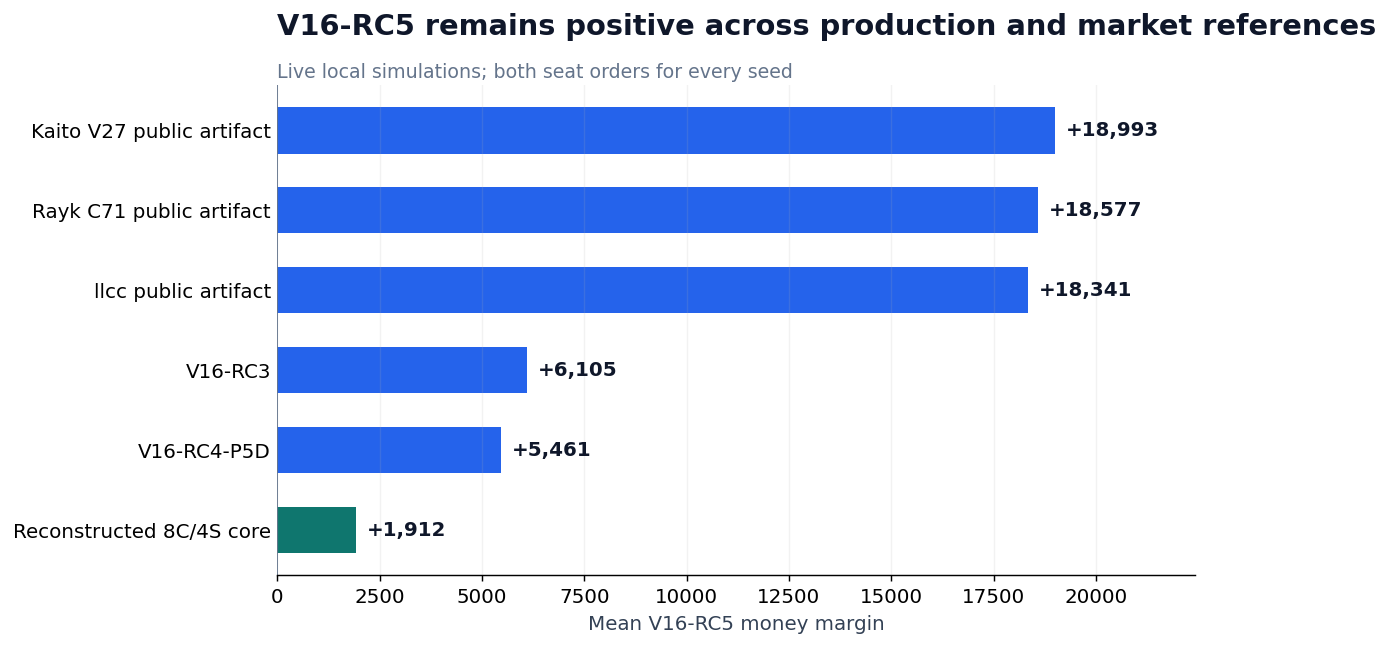

In [5]:
chart = evaluation.sort_values("mean_margin")
colors = [TEAL if label == "Reconstructed 8C/4S core" else BLUE
          for label in chart["reference"]]
fig, ax = plt.subplots(figsize=(11.2, 5.8))
bars = ax.barh(chart["reference"], chart["mean_margin"],
               color=colors, height=0.58)
ax.axvline(0, color=SLATE, linewidth=1)
ax.set_xlabel("Mean V16-RC5 money margin")
ax.set_title("V16-RC5 remains positive across production and market references",
             loc="left", pad=28)
ax.text(0, 1.015, "Live local simulations; both seat orders for every seed",
        transform=ax.transAxes, color=SLATE, fontsize=10.5)
ax.grid(axis="x", alpha=0.16)
ax.spines[["top", "right", "left"]].set_visible(False)
ax.tick_params(axis="y", length=0)
limit = chart["mean_margin"].max() * 1.18
ax.set_xlim(0, limit)
for bar, value in zip(bars, chart["mean_margin"]):
    ax.text(value + limit * 0.012,
            bar.get_y() + bar.get_height() / 2,
            f"{value:+,.0f}", va="center", fontweight="bold", color=NAVY)
fig.subplots_adjust(left=0.31, right=0.94, top=0.79, bottom=0.14)
fig.savefig("dynamic_reference_margins.png", bbox_inches="tight", facecolor="white")
plt.show()

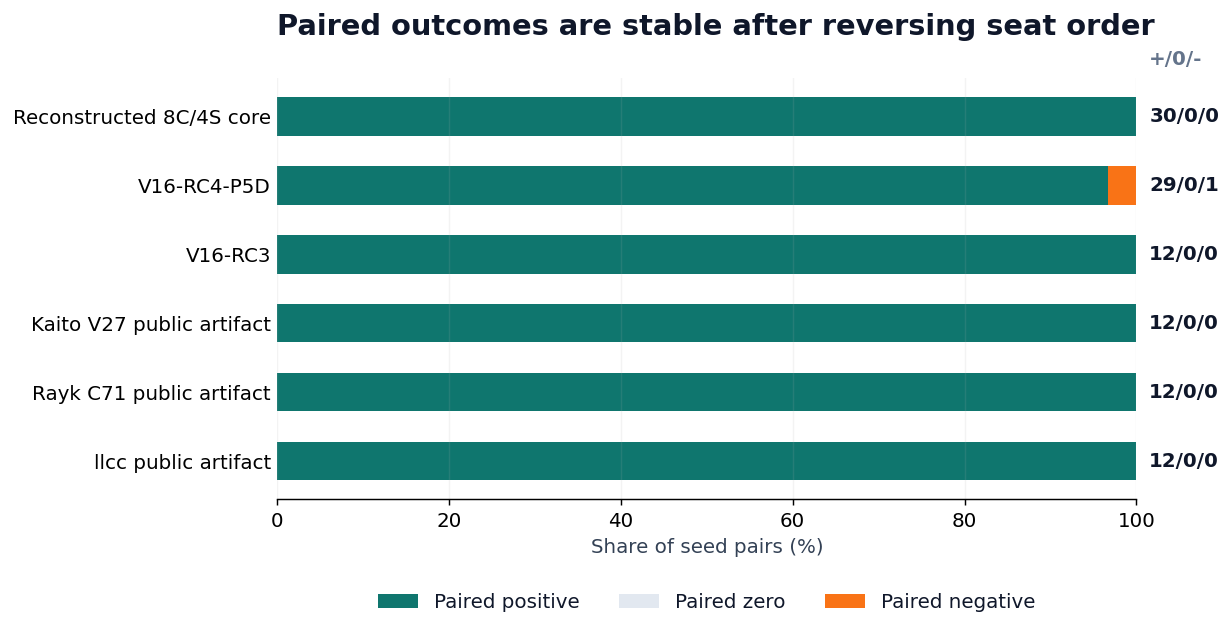

In [6]:
chart = evaluation.copy()
chart["positive_rate"] = chart["paired_positive"] / chart["pairs"] * 100
chart["zero_rate"] = chart["paired_zero"] / chart["pairs"] * 100
chart["negative_rate"] = chart["paired_negative"] / chart["pairs"] * 100

fig, ax = plt.subplots(figsize=(11.2, 5.4))
y = list(range(len(chart)))
ax.barh(y, chart["positive_rate"], color=TEAL, height=0.56,
        label="Paired positive")
ax.barh(y, chart["zero_rate"], left=chart["positive_rate"],
        color=LIGHT, height=0.56, label="Paired zero")
ax.barh(y, chart["negative_rate"],
        left=chart["positive_rate"] + chart["zero_rate"],
        color=ORANGE, height=0.56, label="Paired negative")
ax.set_yticks(y, chart["reference"])
ax.invert_yaxis()
ax.set_xlim(0, 100)
ax.set_xlabel("Share of seed pairs (%)")
ax.set_title("Paired outcomes are stable after reversing seat order",
             loc="left", pad=24)
ax.grid(axis="x", alpha=0.14)
ax.spines[["top", "right", "left"]].set_visible(False)
ax.tick_params(axis="y", length=0)
for index, row in chart.iterrows():
    ax.text(101.5, index,
            f'{int(row["paired_positive"])}/'
            f'{int(row["paired_zero"])}/'
            f'{int(row["paired_negative"])}',
            va="center", fontweight="bold", color=NAVY)
ax.text(101.5, -0.75, "+/0/-", fontweight="bold", color=SLATE)
ax.legend(ncol=3, frameon=False, loc="lower center",
          bbox_to_anchor=(0.5, -0.31))
fig.subplots_adjust(left=0.31, right=0.90, top=0.83, bottom=0.23)
fig.savefig("paired_outcomes.png", bbox_inches="tight", facecolor="white")
plt.show()

## 4. References and implementation

Public replay analysis supplied the 8C/4S production schedule used here:

- Nikita Lugovoy, submission `55440039`, episodes `92165990`,
  `92185587`, and `92223213`.

Public executable artifacts used as local evaluation references include:

- [Kaito Fukami — 25→27 Strict Future V27 Midgame Meta Reset](https://www.kaggle.com/code/kaitofukami/25-27-strict-future-v27-midgame-meta-reset)
- [Rayk Kretzschmar — Findings from Zero to Top Meta](https://www.kaggle.com/code/raykkretzschmar/kaggriculture-findings-from-zero-to-top-meta)

V16-RC5 contributes the cross-replay reconstruction, state-drift recovery,
and the inventory-bounded premium market lead described above. The next
cell writes the exact competition agent.

In [7]:
%%writefile main.py
"""V16-RC5-PremiumMarketLead for Kaggriculture."""
import base64
import copy
import json
import zlib


_ACTIONS = json.loads(zlib.decompress(base64.b85decode('c-qxnO>Z075&SPY&%ylAhjY`~Ojd~2GGsYKVi1c3k|02k95%TH`R~zM<d8F6U0vPp(b}ArE0Z(t`*l}WSAY4>#b1B=`5%Az`QkTUE<WCV`gE}yF8=n@KmYu%=RZ7u{Kro}|NSrje*XOB;=9j({PE-C!~4(go-T%q?f0A8=l?F&yWz{l_jiw*i{QgAKfnEO_rvY|^RM4MY@dH?{`~3t&F169us;05r_JX5^Phj%+&_G{7%pdj-Z$a$_?q2+he?0#-u?db$CKBMJ^OO8-F$lb+OF}#yW4$B$Df@x=VffBBl2l;e}8PpTioguZuQb_>|tal&HeE3`1JkP)*V0Xr_27-Y4GfY`;MzG`R?=G{rexE|M%(hVVt5j%zq;H=l=HH<~aTf>1Br>fw_MErw>o#j7(oT&iZeEnI7p)`){5urrW2@qxazBx{4mW|0W!!LmytIc=Fu&2(m$%?QrzmV`p0C-uC7AT(IRzGj2LFKA4P_KF_ubpB_H%M;Z)L%RJi^dhE*K`AyS&(q1z(ou_#`SjSiPo@QmVTBcbVEPc9d2gcumF`9KHw~P*rJ1$iBPq`64Ihtof-?DmgBhzd392&g2tuGqVayvv_t^zhP_2*6v8fZm%%d9Zy=l;n{Q(wJd-l52T@^F8@dH3|=Z#R!mclURH`Z~kb5J;JG;b?$G2AV-0aJZ6E4fU3G!{{WNeK-nxPSF0Dsf85(rZQIf?b_un-=<;b_z8D=_fFo)yq|iUa}U=z$k#jlWN*5dyZ+Ym_T6qSa_;PC<iy8?^|qk93m)V&^=g-JyM*H`I2cBoqJD%QFa6wE44bAj#6Q=oO&LcaJZKN*O>Gpw5aL0ov}5ktNINEM;E7XNXwz|ED`PWtI!gTk)8&kK*g)oR7tXg97qH2@!~JhLq0@$K%N;faDi^aqe|mbn-F~-ueEj1t*yih9P$^$!pkpcDX;BNMZfY0f>_fK;a;TZ;2(RsbH@4oA2iN;#jpl5F#jfNc4FCeJyp7+x<n{?$eLM^C5H<Th0G<e+3H&g6TQ^-)Q3nimoE;%Bc?d5CPG7_F06Qr5DrrmIkVDnrJFbV=Lb1lgc(Bfb2B`z$_>dWPR<uKB$YBj9>;>BCmpc!VN{$-Yf@)N@dSA6h&}t7X-(bYAo*P(cH&A*@#TSW=-^9qV@Ul4*Y7d+_mA@>w+s8l1@e|}R+ky5%KwVsM5G<=a9Xv)4BY}f%?vmyjxIZ2FF8OuLl<vKrwl^^r$Dd)Z)<)kq^{d6da~qxD@xDvVnru6RiOWwVan3pohv!PR#tVg~HMlF8*PO}jaL|J_p@ntebJbmixjnMXSStm89oY`CL+1N<v8~qbF8L-&KXle{#(EhYHRhT%I>M<U)U?tt+7+Y@W9-UFgr0Z+tqpLz^v2ud<wI?a&mY$Vx^O)IPI2_y_2Wj1PY1BjvIqz&M}7nEx_*Nd5CGOj`60xhI8KG!(PieUR;Q+eS&%?Pz9|f`%EJ(f=?z}<O)l^HOr4tCSr8@>ua|)ihVM2250=afar7zWesR4kUyX_TmZ3@sCPOsD*u|{Gb*+t3GAaP1UkE*jn3B7eX~0oN^?MmF3A@8S2G4N#p!bgtADsy%w$yR6JUra*(^J49J?5u8Upnv2v26QbK>_q?>((trw{Dr+y}B{Uy}I!^<BHLrOuU8TV+~9-yWM9Gsksv%{Uou@*yW~7d*awEglsF;$jj1yz9z&ZwN(Dv(!E`mMMUB2V^_er91=kiZ#$Y+t_e2t7L!3%dY4<mJT@d%W*{giN%GTK;S}`V$Y*P0PlyK6z$}8)=&W?JlpRUHDRBB?5BDUlWS5c6b|GUjU@8El5yC4vxtiuT1UgSNMu>9GGy4;a30*|Vd0~Me5X6#~M+?EzhLm{VGbEnq7r31XuuP481D9rTqX0?|Sd7+svj%M=Z^Q)(1>=L+`06qshBJ#;hKF%^tJouKX363ChoN=B4b;+QfZ;MoWTfKdPhX4TC;dj-ZUfMSagDsc`yFmdtF1#aqun7MT2hrNw?Na|ln*AKwLGn<*CrAf(qQX#z~f%k{F@wVn~IbkS#(gpVvY*r>~G(-5j+*@Be)*fvU(~}<Nx&B9Y;*SMwhz|NtBU8lJPv0q$2EXSR+PX373i4)*TAhrb(0ilE)^PgK>d$PN0Rh;`mnY)@TmS+q-aXo-{(?C&4@1>r6tHLe&HosOvp;B~LhZ)NJJ{>jxOvz-T<aZya^wWyZ^dq3_m?ficqDRm)xoO_%7PtRz0z?M!hCBiB>RZgZJ;9vW~Q2Dol86};1F<XegpYodYcV$U3e;7F4&zmKnW74Z}MDuAuD@F7@8%I>FLtIW%!sPQtGG|E19MtdTHZdr?b@uoHG&_YRNPER&Rk(>2PY$|Z8zM7gyZurQ0u0;??T%4N5B^z0eo}*XW8Sj~^3GVyQOjZwac5Ytp3N{{UV~MjNu_7QnUQ2-MpNDFPz}oCOw%@iY#swLzgHq0-pBkHi`r}uNh(0wL+W0)+CBP0F&`zi$*v#e!W*1mxErAPU;vwa;$c2lyI55W1^oDMuJ2**^5rDzlKgpTJ`@{5yyZhe@HVwK&5cdgsD@~q=wNg$W%^a3;vP>!`=eWG1v#f<!teA1SNv<RxM?0ynb|IPW4*g>kpqnYp?c9dB(owJLNaqA|_ZC+r8q-vu`nnUkzjT7`x*uSJjv!dTzSKnIp2-DiZwMMo$tq3BUI6GaMgWL`Zv|&a{91pw*-O$GIIDx><c(dimWjnis(z5|FAMgFU9S1g)Tad&y#>Qg#F(}DV8JZi3j^}lcKxH(!@W0Z;Ol<ey6nfH#U<DTP@$a2->bN8Sxg5guhjMkNWMayr4u(BiHbz*;9;j`S!<I+xi<-?aX!f~nn5(G(Wu%UjA$xwM4a@MO`M>xH$-0WQYUJELpY;OwGcsE$f}t~96Ud=HT#M4XBsvm!uByIO`$q4KRZVMhv4hfJ4O8!M3enx?G8;Ik7NPU@gK*v4;+2krTIF)@|W@@*#TEQ7c@h1atoT8kJ+IrEmwR5@ij<|8?Z-bCm=n>EYP5w&0rDQv&K?3VMhXhO7r=XI&JF8W7ms43Egv;+N6b$7rOAlx)~1v;Lb-)CYS)I*P+BK#{)%QaBQ?}yCD4O;}`6iO@e#gk>rC%;Zh<-G@E3<4A}g14~SnHLEP^kE8L`jPRc?n6b~6XeK-^GR#}(lK*RjxHUSQ^23A%GV4Yw=qDEISqDE{BHHD#Dtu3j+R-s|!Z(it<yE#HNnCcAi`fe}|LMXM+y`Lx4UGO=$gkb#Dc!v~xNsM7LcaD&;sLUu_1cg|(n{1a}mOM&pVZAE5AoS!3VoNnWa_s3O3xUIAM0k?JoG1#ljBOi+5!g*baqbM_Z5wi8%I{OGn9)kdH78ZGNDNZ!I;A!WI4etOmTWY&I|5?u72*WtY)j|^W2b7=s-#9Q!*@x@f|ZD@@Jlq6vFrzP#?+KmnX^pGs_@noq)Pg_7v0z~I=%NB3`Bvg(joWp|H!?h4NnQ+Va_#(a3Os=(YqYKc6zxl-G5o=?&pmz_yJY>0GFBqpp=x^QdvjN)bxm$#g;Vj!r7g2W{(+lS|)L-1do=iKs<X1hr=4S<B!B32VC(|DiD}r>K12gJy}Q*dpMB1NjO{yIyO-#wnGHy$y(AUjmY<4Mo>`%Ns)s~e&K|qIKW1QKf=MI8$PpV?fOHdD10v#q+d|hOVhf;djR+vFu)8q4RgL<$lO=W6|TTG5hfcAsF!@{SO|eqfpzXU3<XX<HXE5^kcS1~7GZ3k6FT|nC80ZXsAO7$u8=iT1g1w){t5B<8P|jzhq-hEyN-<R3qV2jM33=l)7h--0gIt&HE%3C#T6;nwRTM7GHp{xyi%kxo?okrn`%Xu91Bf`bbrvTf7Nd5d19a~iNT3@ClDmn;_x{=81>Wnqn@%rDb5?|9ac)EA*VRh0*R3Y$a7FRBeB*Zn=1Qk>r&4<SC=57J}j*-Rl0Q9ukb+ZuMx~x3~Fg(N&+@$%QkaRD>5=c?lFm;XApcbWtPTY+@Ms|8V3(d5GZqRwT~g3>B>8KVz4es6q&F9|EkVA(v$TWOtZiA910lu-grw<(yMMtn})b>Ru8%%f&0Ww@$;c<QcGVU?_4f&L{N@$g&HKF!sr?QOXo13^2&lV6XAtgN7DX<v0%Th)AjD$A-$F^D)jJj;i_dOZr3GA+K<~cRs8TD3ry7@`KwT!LOANYQjDBa^jei2Y$G+|UEmJ@_wH?bq3=jCUoRBS%)5HMFfq=M{MXb@IVG@xh~J=wtrPYy+X5_{M8kvqVq12p$BZ?S*IzN!B&gEE!Y7ct9iR+5IuT;f>bbLoJ(_@7Ft7RkQB2tOAwX>a)+&>@(CHQFnjN8_19eLZY<?z$5^gfcxjkL%4cA}VJHz_6jXYmc+=5A!p%O9X3~PEj3v{_kt_}0Eiv2EHgCSbjpoYqfyIC72g4l%sU>9X9Fe=A4SP@xDR3!<UU%jJ6#*GKu*n(VG53Q0{rD3v6$jH-E3r0*7!)_+c<tR*ryJ;=u0(X;DrI>OxDUoE5at1jyvxl-&!C$3OGsiz|6t~J(dsjK4RJT|vc7b)`*1NK-t0E`M<<TnEpLBng(!v@{9dZ3<3I#x`D46@omay}Q#jYr!ZnQ{xYz`t|Is|TQD%V8i#IeLdPxFanGv!207$-C$t`ag|2H#+US0u<q1Btod62l^qB8ytGMyMuNt^LlZrI9L4s<K<Kis?X!!PoQPbo?+r9huR_<^@pV7}-J~Lr`4hn7d64H|pHxvM4v<Y^VrOOPQUNT4PM;q}u*_6T6~`0>pSE8f)kj61u1Y;x{>@lEAABNy3{e?-4GF9wD$mm#?6&oJq!OkWntg!dpUyeUxONm$-8OC6s4|zq-Vmf2vS8NF}4BI^ceqqJC&8nmc{shC(=#F!TgJ`WxstGY>Eu-J~i<T-t@BGjjAZp{19pzT$+H*lnvhTg==#r49oqIW8q4N?#=We5uYVaD1Ra$g&|-dRR*~JS*O;Wn-ea7Iqax*SnR%9jd1?4R*F?nN(e=91a38P%KBs<-GmM0_L)xv{Zs-VTH#bC|@qh#PcJn6}N!+CO%fUA5H1Y!lIE1>yRuk5F>;bvUj}Wr5R_LGU=qIKs1lFZiHi1TP6U_#X|_L6+M1Uc{Cyk0UD$?yG(!BW(@+}xU3R9dlVfPDc6a~0R?+F5Gux-z^m@r04LkxEON4Il%-9T>6CEyISPK;{vxLU^UoO3upvK<qYH?ZV!q_H*i}Xj_w8bR8o~7n50`4xS|W5C5l9PDPkfq}%u!)=k=kN0Wg#mx)jeJI8}q=E1-K^Q4`vYbXNb3C&B|2qVrFA9;_o^OA))!YbcllN*}!4QaK4J(7D!Mfe6VdTCM>A|3sN5h_GY<k^K&=>jVjAcPx7TwB~6(+V2Ti!K}y5by~oz2#|s%zA2U<ISe|n!ASSF<QB1m&WvUz+A{8l)i`fV!XcFoqp2q}ly=|13DNQnPRdpA2e`qZWG<z5WiP@x+(8F4Az`!fRsRK6!?3ZdhD?=FU$?Zm<hOiM#KxD3J+>k*zgMmu$Kq5jH(>OZu=4uYHtV9XCEPdxq&nJPu9Nx_e_QuAm0Nw+ei}4GsdoUeWWxlLGb`mqSN=-5Z58@DAvd2Tto0kkcP=J6m>UvkH>O48UZeEjp-ic-K%4)!@ZnGf*R1|C>dA5aTwCzOamZW>+qqW?s4#GZQ=-5fhwJ7^Ew&tmTj>uZUA(-B!N{p7E7omhXvEEz&Ox4lGJaFdA@+zNa)YPV+YM8y-S4>N1_DB3}VAaOOfzPoS8Cc<)8(~bVB4@VVm6$H!hQo_Jj$;+%2NxLz8>c+eWQfL+E{qzzl_ZU~Ay=ELJ@wMr*fNGeO4c~T1*x!CB*ikuNMw`WAeA7cfKX9umFC2Qs8jHGUBf0qL;z!Df%!@5fK~<*!T^$Pq!-#Hj@HetR`S*X6@5|v^w1R`WGx!X)UxdXW{cY+f{cmBD>LBXx{Qz^Re++|2U5YLTKog5dfNiJ%__u`75w(~RmD=(mU`zMw8xcwO|Mc~0Xvv{GQN{5pht*%)wfj;j#TD)I@(<kh2Ez5l~Oai<^@DKzf8#|xJQ`GXfEMYijwOJR%ql8H72Pu&$EZ?{sl~J#JK=^Is-{JMn2zR0F?Pis+-Z|fvE1PHxOR;&ZUaRBk&|0Uo4SYOGph}r0MYKQA%G8D^N8FXMswHF@uiCGz)}pd`3AMy0fYpZ+EGxp|<IIr4lW-%B_vtNq8@+m8Rv*&@3d9AH*lc<UztD*2Xfg>^2V+K%`7EQfJ1?jk69&<q`yEF*&=mI(iu)YN191<^{qkOcd>OV!&F4MNDH>T*P=u=vE6&qzGs;H6tqs=M_0jz{d3kr*Oy9Ng#+Vyg~5p7K?Ou+z~1nR@&Sy!%@Y7>&u>@Vv!x_WF&xtx<V0(9J9hUWx9ZF5rTfg6OB0p7BzW+isEzeYF8<|HKB>TF+zS<X&?p=n*)%hRQI5onb4?VvA+8CsoQfv>9QzHQ43YedV+b%N?hKxxSfw`MnbVvesSe>)g>_?hX<zn)x@bI`CW3rkaxCb1Uct@BEu|<Vg{ZoyTT=LKs=Y5`-cypHtkm7eg%e6nl7W+D^0=`Bn#DUDkyPA_1wjnbZROjQ46W48q0omTqDQk?7_(@g3^fX(yI9a{&eKcnn43AfLKNQX<aN6wY)`<9j!VXi?z>=n1m=)0!9*UNbd%N6iHHv86U|kt-{-NT9pT@Xa~YpqRY+>7NG~WSUl@OKoVeldr`d7aqHVMNeD{VR62B=$8eo-7Os<I5U#d}ZLKXA$!4O$jM@A*uRrsaa5|L-rSiPMAjlX?Yn7IwNd1FfWA@FoY1pz#tvG>h0|Ye5We1rfHUtm|yl~$uBNfdAQDNj-6(DA}uVZQ3%%E*PiWgjpL|H_{f`LlOJfNfGNU{2=mXl>kMtc00Cx2!NalSpplJ*zo<u1`NuBKx9A0}o^rq<7`BMLC~6b6ba5I0&jgL8`;Fre#BJgHjgQN~xS18y-;FQ$IId)OYzmLP%i^VJersztV(*s5Zxz~*zPsTWbJ5BCO`?NNFQ|7OhGY8A4Gij+{{KGHlA$DJ!EcNV&U{eXujmte(T_{x#^c4bWj5zUx)FRR1DUCGUtL{1ccP_5F3l*bvocq7TRGH}0B?e4&@W<5KpTDB+gFeBV0_?&5L21Ou(xGlGFs{A)8nKQ`yCA3J(0mVxxI!~;D|J~=i`}aRS+b2(-A7kx5o~A=OfD+5)g9O;X&p&>*nOHC>nIG#CfR-Kxy_B=He*-#7$UO&xp#dIAMqObAg9-$>LUoJCDBu~L=wCU=(xs*^LAnE<H`3e|OZ7-#56N_fP+=5)0HDWVl}~LI!@17LXuh#dpP;@6r(Y-^r5@;Uk*j2l$9<`wbvfvaSJgO~Vwz+`PwFaB5XAJinyE}wiHSUMoOa9+v8}392udOyuqm&4S*o2@|3=TE;P4aSdXaG8OmA#}yL#P>&#c~jyHc;`<VBsMK+mdwW?c#kC{ma>oD$Q~edwi_<3nUfL^!3QHL>WxJ7Ps|A|_EnJ4L1u>9t68nOdK{AD&A$J3aG`hPgu@yiKuV2-ygBKXJpC>F7uxNNp=2K{*p)3+fY)6rk#cK_jFq4=cqg8bp5NEI2ReBT<ttS$?wwEM_Ylc;<SpAxaIipd3g=>yZ|=AbD6p14ucV+^|SXNzbxk^T^6une$D_Xj3JhSaKTy3K$Oa^$3bYpAuL!Ey|N@oJ2{%*A&r07M;Z0R$$iwzZZyGRVihZDpx8OAp@B(xgj&_jH#-S8ra0s3~f8IoJ6e^<d8B6naWC1bWmA43Z+l1*l=DTcKw>pYje4gN`jIj`P9p?y{tO6@M%|S3D%gseAY@P%#b2~(H!Nh))BIBf{G_zNSpGg`H=it3Z<xJ;3BSAQ*9MAX!<oqU2XI=6Ff{*)VbVM!sih2P)u9ZhGdM^gts^6sSXXHc<ilE@fqgqI{`s8bbaPzm?%XI$LEt$G<La)p=F7B*r$M|Q(G@`Ad*#FV;c;F&xwn@C7f1~KO`zMY&YEtP<qa=&bX$@B_iBaQFILhw(#U|5?Uw>!KH~r&6|wUf@Kqld=kcfXR2t)?JtBqodqVB4GnNBYDSR^nnWEkv}<$`<1I+Cs3Zc@V>CJ&COW7$6+#Eo{o@u2;zQWSk^`W8w50%KhTcmlKh#kvo(=wPq7dLo9-~v5HdsT!!c$VwjqYe|5<xDGfHVg67OkAHU9N7`sGPar?D~-$YA`E>Knj}8?2CDVc@@bg#tg_|m&rx8GvFWR-^u}>im0>2hd?uk#<FdyTJ$_F=yf&`V+BehC4Aembef7T`RLfHScHkDH7fZk#hObQ{)Z?A(}KoDScjr$6LqP3&Wu)RDWy%)A5_D3YZP)pu9&EgQ)JyU+a|hjWhGsAvt=w-US^5grJP62eR7d`v)bvTWUhbfo(HU%S+PjD&=Qn|m~+L5mKbrFTk)r8YXUoq31+~vS8;(@NbODRfO(oOv1FkP(lE_QF`M)<L(rmchKpW}Ds&=ip-*--hnk}4U8nN5d@MA~;ew{MPwG!@!j)3^B|=P&$rQX`8^_>$_12;S!d6J?Piq6wdR&vUV(n;QuQN*0o)T}3Du;ITT%}1-15MNmb~$Mo`A4Ei)mot~kn&|>dLcx~2xN8?t=NJcsKZVhC(V8kw6vuLzRd`OixL_n)DJj8Uh-{>S-t61ElO!HO~7Wh#4<<EsgPNwNM6UP&1aU=ZOkiKdr+>zwpm4ll_q2%Su|NB(@=V+-Z&|kA5dk)*10C^83-{f+XVJOwqBFPwibzW4n*To8UGZiV#Zf<LR5n1B9b5MHPEXvlFzdbIMQ1^zEX&|Tsms$9Xx1FmtKsJixQ_Yl70>PEk~cy`CS4Hi|~|aCGUjvTs9$v7FyYeQRWPb1{h9c1BDQW64j3lz>GA~Lc$$`0_lEnr2xx615Ja_-Q`+Vn)}OqpEeE#M{Psok`Fo)1DC}dR`Cf#VW=o6pQ#T~qGK_H&B>$Stjp%b={3Tx>imx_Meo3wSQ55P@6a%L0G>I4f)}IMlOvMrGUpal!%@SSE$m#UggBDb=v18>+zAs)KM~vj>=3=sDXSvJ6j&+V7>f#{d?-bhByTv1QzR%M*XkvuG%?apA_LCKf*&CsNb;f1mLb)S!*tX4ScOav%5>Cjr?+ujOeS?CYZS5PhV5SOI_rgK13hv-Hw96t^U8;aY*%(0>77~aUQcmEnkbSpRHT|{jCGoy9f?{tqEf`D;-TX(P)s4Hf(jgMm&Ga_S$f~OCVbQ^X+tdVdtPZ1FZo18tQaWu!dFtt(C8GKNaAEG%%Orq6`>}MVriNg0cKiiU|0i&m*1m@AKK0(FoVvEy_RO`K+y@~Er>>v5<R?g_Ye0tw+i<(K?maEjG!}IjMUgKtlm-u&W-BJI0C+@igAf^D3SMDOZuP=d_)kUg(WFcRtRkpP%}u0U>wS-l8Vy4aK?G&7L(4OCbiVssX?%QJP(XIDME_U7E0xhVX_F|M@fAVbYr-5OVX!fZcnByS+$jlu*{)a?cj$!UrQY|iJE}sUw6xvkpvF|#*6#Cl@F}w2_9;845`YNR7nYdkjaJ@q$fo#O(_sXGn^a9EvhC<K*tWGIO28!8%LGL=0+LI11hdbvF<Uh-CcxZTJZ~}E4kGx#whdAgW?`(u~0`t#D63mOOl7d`DZHYhq#!zpsZSin--S_yQO8-Ve=M;iDVeEievUzmsDCRlSva~$PoxB=ZEuDN17N%2?%P!n*w;ntE5rVpNe?qE~Txi!A_$CaMPy_02{{JD#E=00kBE#iXuwLI%hRW0%IcF$x(tVs6@&kbz4J}qR@8m1CXCZ=s}8tEeezpR<zAy-lkITf_dKCFjBF|B&CE|Yy?-a)!IcF93vJmJ#mFli){=^cCb<rWD*4BV}CT2)(})#YK_T3+BMJ|)>nNT`7Q#nZDfb4X+a~eK~Xc;LtnT*ZekM$J{q>V6(6pLjmEr{gcDA=mc{zzTS2QKtM55K@&qDV*y5=E8m>&s>>_Hw)yk=JN_!%EM`IthPB}|WMwY7okGY6qpb`-o%u>!zZfsJ;&(N+Yxq?(qL`-r-Au8#hD?luIppeM+De6E$JLb+}Gr<SBn)AGIoE5`Q?;LI-SI^wYr0>i|jczki@?_x03&5fZRNBi-T0UiW@C1A@c3Vu$_k-5n%o1IJILlqovmT91%Qd2>FA&O9q!tb-1cO!(%(@heT23RKu(m3x!_geGq@ZUYhT>PxN%>!m402b0C{KJ>=-%XmQayu&%=g>jDzUr@uNGSs+)=Cpm#fa<<<MKql~fLm24|=7HmL9?yM$~zT&<^^HOmoS(h#9EayB4HEk4x*Q`A&athGRcCZqVPTzwNUpQXEBia~!mP<-Zt>djLe`(~HPrEU`AQ_D<Nniw(65~Oq*O|5cT`3|6bOSY`*>=H#<Q4BRF8kNHf&@1!`tjNGlH7#a-#M>ag4vIh|%MocU0Gb>*CcGA>pT<Z_3Uz_YK0@`Pk)yw%KTa(;wBDHlKl_#rq5z11nhcamYy)qZNQz~dij7k>Z9_C_=49seZE1r+oR&z?fp5=$$FEHz1hZ7emo(()!<&BsESow1n8whSLh<YU%cyThLXAYi{v_TMI(Ms#cUP#!NNQ_VM31gB@_4)d?*0c(Djk>')).decode("utf-8"))
_FR_ITEMS = ('MELON', 'MILK', 'STRAWBERRY', 'WOOL')
_FR_STATE = {
    0: {"last_step": -1, "due_step": -1, "due": {}},
    1: {"last_step": -1, "due_step": -1, "due": {}},
}
_WEED_STATE = {0: {}, 1: {}}
_WEED_REPLAY_STEPS = 8
_SHOP_PRODUCTS = {
    "BAKERY": ("EGG", "WHEAT"),
    "PIZZA_SHOP": ("MILK", "TOMATO", "WHEAT"),
    "BRUNCH_SPOT": ("EGG", "WHEAT", "STRAWBERRY"),
    "YARN_STORE": ("WOOL",),
    "ICE_CREAM_SHOP": ("STRAWBERRY", "MILK", "WHEAT"),
    "PET_CAFE": ("CARROT",),
    "SMOOTHIE_SHOP": ("STRAWBERRY", "MILK"),
    "FARMERS_MARKET": ("WHEAT", "CARROT", "TOMATO", "STRAWBERRY"),
}


def _get(value, key, default=None):
    if isinstance(value, dict):
        return value.get(key, default)
    getter = getattr(value, "get", None)
    if callable(getter):
        return getter(key, default)
    return getattr(value, key, default)


def _copy_action(action):
    action = copy.deepcopy(action or {})
    return {
        "farmer": list(action.get("farmer") or ["PASS"]),
        "hands": [list(order or ["PASS"]) for order in (action.get("hands") or [])],
        "market": [list(order) for order in (action.get("market") or [])],
    }


def _seat(obs):
    return 1 if int(_get(obs, "player", 0) or 0) == 1 else 0


def _farm(obs, seat):
    farms = list(_get(obs, "farms", []) or [])
    return farms[seat] if seat < len(farms) else {}


def _align_hands(action, obs):
    action = _copy_action(action)
    expected = len(_get(_farm(obs, _seat(obs)), "hands", []) or [])
    hands = list(action.get("hands") or [])
    if len(hands) < expected:
        hands.extend([["PASS"] for _ in range(expected - len(hands))])
    action["hands"] = [list(order or ["PASS"]) for order in hands[:expected]]
    return action


def _tile_at(farm, position):
    try:
        x, y = int(position[0]), int(position[1])
        return (_get(farm, "tiles", []) or [])[y][x]
    except (IndexError, TypeError, ValueError):
        return "LOCKED"


def _trace_actor_action(step, actor):
    trace = _ACTIONS[min(max(int(step), 0), len(_ACTIONS) - 1)] or {}
    if actor == "farmer":
        return list(trace.get("farmer") or ["PASS"])
    hands = trace.get("hands", []) or []
    return list(hands[actor] if actor < len(hands) else ["PASS"])


def _weed_repair_action(obs, action, step):
    action = _align_hands(action, obs)
    seat = _seat(obs)
    game = _WEED_STATE[seat]
    if step == 0 or step < int(game.get("last_step", -1)):
        game = {"last_step": step, "active": {}}
        _WEED_STATE[seat] = game
    game["last_step"] = step
    farm = _farm(obs, seat)
    positions = [_get(farm, "farmer"), *list(_get(farm, "hands", []) or [])]
    unit_actions = [action.get("farmer", ["PASS"]), *list(action.get("hands") or [])]
    active = game.setdefault("active", {})

    for actor, transaction in list(active.items()):
        index = 0 if actor == "farmer" else int(actor) + 1
        if index >= len(unit_actions):
            active.pop(actor, None)
            continue
        age = step - int(transaction["start"])
        if age == 1:
            unit_actions[index] = list(transaction["intended"])
        elif 2 <= age <= 1 + _WEED_REPLAY_STEPS:
            unit_actions[index] = _trace_actor_action(step - 1, actor)
        else:
            active.pop(actor, None)

    for index, (position, intended) in enumerate(zip(positions, unit_actions)):
        actor = "farmer" if index == 0 else index - 1
        if actor in active or not isinstance(intended, list) or not intended:
            continue
        if intended[0] not in ("BUILD_PASTURE", "PLANT"):
            continue
        tile = _tile_at(farm, position)
        if not isinstance(tile, dict) or tile.get("kind") != "WEED":
            continue
        active[actor] = {"start": step, "intended": list(intended)}
        unit_actions[index] = ["DIG"]

    action["farmer"] = unit_actions[0] if unit_actions else ["PASS"]
    action["hands"] = unit_actions[1:]
    return _align_hands(action, obs)


def _fr_state(obs, step):
    seat = _seat(obs)
    state = _FR_STATE[seat]
    if step == 0 or step < int(state.get("last_step", -1)):
        state = {"last_step": step, "due_step": -1, "due": {}}
        _FR_STATE[seat] = state
    state["last_step"] = step
    if 0 <= int(state.get("due_step", -1)) < step:
        state["due_step"], state["due"] = -1, {}
    return state


def _town_demand_now(obs, item, step):
    demand = 1 if item != "FERTILIZER" and step % 24 == 0 else 0
    if step % 4 != 0:
        return demand
    town = _get(obs, "town", {}) or {}
    for shop in list(_get(town, "unlocked_shops", []) or []):
        products = _SHOP_PRODUCTS.get(shop, ())
        if item in products:
            demand += 2 if len(products) == 1 else 1
    return demand


def _future_quantity(step, item):
    future = step + 1
    if not 0 <= future < len(_ACTIONS):
        return 0
    return sum(
        max(0, int(order[2]))
        for order in (_ACTIONS[future].get("market") or [])
        if len(order) >= 3 and order[0] == "SELL" and order[1] == item
    )


def _pickup_reserve(action, item):
    reserve = 0
    for order in [action.get("farmer", ["PASS"]), *list(action.get("hands") or [])]:
        if isinstance(order, (list, tuple)) and len(order) >= 2 and order[0] == "PICKUP" and order[1] == item:
            try:
                reserve += max(0, int(order[2])) if len(order) >= 3 else 1
            except (TypeError, ValueError):
                reserve += 1
    return reserve


def _existing_sell(action, item):
    return sum(
        max(0, int(order[2]))
        for order in (action.get("market") or [])
        if len(order) >= 3 and order[0] == "SELL" and order[1] == item
    )


def _repay(action, state, step):
    if int(state.get("due_step", -1)) != step:
        return action
    due = {str(item): max(0, int(quantity)) for item, quantity in dict(state.get("due", {})).items()}
    action = _copy_action(action)
    market = []
    for raw in action.get("market") or []:
        order = list(raw)
        if len(order) >= 3 and order[0] == "SELL" and order[1] in due and due[order[1]] > 0:
            requested = max(0, int(order[2]))
            reduction = min(requested, due[order[1]])
            requested -= reduction
            due[order[1]] -= reduction
            if requested <= 0:
                continue
            order[2] = requested
        market.append(order)
    action["market"] = market[:10]
    state["due_step"], state["due"] = -1, {}
    return action


def _front_run(action, obs, state, step):
    if not _FR_ITEMS:
        return action
    private = _get(obs, "private", {}) or {}
    shed = _get(private, "shed", {}) or {}
    moved = {}
    action = _copy_action(action)
    for item in _FR_ITEMS:
        target = _future_quantity(step, item)
        if target <= 0 or _town_demand_now(obs, item, step) > 0:
            continue
        stock = max(0, int(_get(shed, item, 0) or 0))
        reserve = _pickup_reserve(action, item) + _existing_sell(action, item)
        quantity = min(target, max(0, stock - reserve))
        if quantity <= 0:
            continue
        market = [list(order) for order in (action.get("market") or [])]
        existing = next((order for order in market if len(order) >= 3 and order[0] == "SELL" and order[1] == item), None)
        if existing is not None:
            existing[2] = max(0, int(existing[2])) + quantity
        elif len(market) < 10:
            market.append(["SELL", item, quantity])
        else:
            continue
        action["market"] = market[:10]
        moved[item] = moved.get(item, 0) + quantity
    if moved:
        state["due_step"] = step + 1
        state["due"] = moved
    return action


def agent(obs):
    try:
        step = min(max(0, int(_get(obs, "step", 0) or 0)), len(_ACTIONS) - 1)
        action = _weed_repair_action(obs, _copy_action(_ACTIONS[step]), step)
        state = _fr_state(obs, step)
        action = _repay(action, state, step)
        action = _front_run(action, obs, state, step)
        return _align_hands(action, obs)
    except Exception:
        farm = _farm(obs, _seat(obs))
        return {
            "farmer": ["PASS"],
            "hands": [["PASS"] for _ in (_get(farm, "hands", []) or [])],
            "market": [],
        }


Writing main.py


In [8]:
import contextlib
import gzip
import hashlib
import importlib.util
import inspect
import io
import tarfile
from pathlib import Path

expected_sha256 = "f029fa0cb66a9eb509afbe44e3f59b800332d0419db91607183410e4089c4d19"
main_path = Path("main.py")
archive_path = Path("submission.tar.gz")

source_text = main_path.read_text(encoding="utf-8")
with main_path.open("w", encoding="utf-8", newline="\n") as handle:
    handle.write(source_text)
agent_bytes = main_path.read_bytes()

assert len(agent_bytes) == 18946
assert hashlib.sha256(agent_bytes).hexdigest() == expected_sha256
compile(agent_bytes, "main.py", "exec")

def load_agent(tag):
    spec = importlib.util.spec_from_file_location(f"v16_rc5_{tag}", main_path)
    module = importlib.util.module_from_spec(spec)
    spec.loader.exec_module(module)
    assert len(inspect.signature(module.agent).parameters) == 1
    return module.agent

with archive_path.open("wb") as raw:
    with gzip.GzipFile(fileobj=raw, mode="wb", mtime=0) as zipped:
        with tarfile.open(fileobj=zipped, mode="w") as archive:
            info = tarfile.TarInfo("main.py")
            info.size = len(agent_bytes)
            info.mtime = 0
            info.mode = 0o644
            archive.addfile(info, io.BytesIO(agent_bytes))

with tarfile.open(archive_path, "r:gz") as archive:
    assert archive.getnames() == ["main.py"]
    archived = archive.extractfile("main.py").read()
    assert hashlib.sha256(archived).hexdigest() == expected_sha256

def valid_action(action):
    return (
        isinstance(action, dict)
        and isinstance(action.get("farmer"), list)
        and bool(action.get("farmer"))
        and isinstance(action.get("hands"), list)
        and all(isinstance(order, list) and bool(order)
                for order in action.get("hands"))
        and isinstance(action.get("market"), list)
        and len(action.get("market")) <= 10
        and all(isinstance(order, list) and bool(order)
                for order in action.get("market"))
    )

captured = io.StringIO()
with contextlib.redirect_stdout(captured), contextlib.redirect_stderr(captured):
    from kaggle_environments import make
    env = make(
        "kaggriculture",
        configuration={"episodeSteps": 720, "seed": 451781128},
        debug=True,
    )
    env.run([load_agent("seat0"), load_agent("seat1")])

final = env.steps[-1]
statuses = [str(state.status) for state in final]
actions = [
    state.action
    for frame in env.steps[1:]
    for state in frame
    if state.action is not None
]
active_field_orders = sum(
    int(list(action.get("farmer") or ["PASS"])[0] != "PASS")
    + sum(int(list(order or ["PASS"])[0] != "PASS")
          for order in action.get("hands") or [])
    for action in actions
)
market_orders = sum(len(action.get("market") or []) for action in actions)
assert len(env.steps) == 720
assert statuses == ["DONE", "DONE"]
assert len(actions) == 1438
assert all(valid_action(action) for action in actions)
assert active_field_orders > 1000
assert market_orders > 100

artifact_table = pd.DataFrame([{
    "artifact": "submission.tar.gz",
    "root member": "main.py",
    "main.py bytes": len(agent_bytes),
    "SHA-256": expected_sha256,
    "smoke frames": len(env.steps),
    "status": "/".join(statuses),
    "validated actions": len(actions),
    "active field orders": active_field_orders,
    "market orders": market_orders,
}])
display(artifact_table.set_index("artifact"))

,root member,main.py bytes,SHA-256,smoke frames,status,validated actions,active field orders,market orders
artifact,,,,,,,,
submission.tar.gz,main.py,18946,f029fa0cb66a9eb509afbe44e3f59b800332d0419db916...,720,DONE/DONE,1438,1772,1220


## Takeaway

A stable high-throughput route does not need a wholesale production
rewrite to separate close matchups. V16-RC5 keeps the reconstructed 8C/4S
farm plan, adds narrow recovery for route drift, and moves only available
premium inventory into the preceding no-demand turn. The result is a
repeatable paired edge against the source-like core while retaining strong
performance across established public reference strategies.